In [2]:
import pandas as pd
import pyodbc

conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=localhost\\SQLEXPRESS;'
    'DATABASE=olist;'
    'Trusted_Connection=yes;'
)

In [3]:
query = """
SELECT 
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    SUM(oi.price + oi.freight_value) AS order_value
FROM orders AS o
JOIN customers AS c ON o.customer_id = c.customer_id
JOIN order_items AS oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
AND o.order_purchase_timestamp >= '2017-01-01'
AND o.order_purchase_timestamp < '2018-09-01'
GROUP BY c.customer_unique_id, o.order_id, o.order_purchase_timestamp
"""

df = pd.read_sql(query, conn)
df.shape

C:\Users\Abizar\AppData\Local\Temp\ipykernel_11332\2329269807.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(96211, 4)

In [4]:
df.head()

,customer_unique_id,order_id,order_purchase_timestamp,order_value
0,871766c5855e863f6eccc05f988b23cb,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02.0000000,72.190001
1,eb28e67c4c0b83846050ddfb8a35d051,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06.0000000,259.829994
2,3818d81c6709e39d06b2738a8d3a2474,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31.0000000,216.870001
3,af861d436cfc08b2c2ddefd0ba074622,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35.0000000,25.780000
4,64b576fb70d441e8f1b2d7d446e483c5,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51.0000000,218.039993


In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [6]:
df.head()

,customer_unique_id,order_id,order_purchase_timestamp,order_value
0,871766c5855e863f6eccc05f988b23cb,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,72.190001
1,eb28e67c4c0b83846050ddfb8a35d051,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,259.829994
2,3818d81c6709e39d06b2738a8d3a2474,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,216.870001
3,af861d436cfc08b2c2ddefd0ba074622,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,25.780000
4,64b576fb70d441e8f1b2d7d446e483c5,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,218.039993


In [7]:
import datetime

# Reference date = day after the last order in the dataset
reference_date = df['order_purchase_timestamp'].max() + datetime.timedelta(days=1)


print(reference_date)


2018-08-30 15:00:37


In [8]:
rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('order_value', 'sum')
).round(2)

rfm.head()
    

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [9]:
print(rfm.shape)
rfm.describe()

(93104, 3)


,recency,frequency,monetary
count,93104.000000,93104.000000,93104.000000
mean,236.702924,1.033371,165.117718
std,150.942219,0.209012,226.361168
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.007500
50%,218.000000,1.000000,107.780000
75%,345.000000,1.000000,182.425000
max,602.000000,15.000000,13664.080000


In [15]:
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


In [16]:
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [17]:
def assign_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 2 and m <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
rfm.head(10)

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Potential Loyalists
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,New Customers
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Lost
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Lost
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk
0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,1,4,414,Potential Loyalists
00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,1,1,411,New Customers
00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,1,5,315,Hibernating
0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,1,4,114,At Risk


In [18]:
rfm['segment'].value_counts()


segment
Hibernating            29465
Loyal Customers        14212
Cant Lose Them         13063
Potential Loyalists     9120
At Risk                 8618
Champions               6496
Lost                    6265
New Customers           5865
Name: count, dtype: int64

In [20]:
segment_revenue = rfm.groupby('segment')['monetary'].agg(['sum', 'mean', 'count'])
segment_revenue['revenue_pct'] = (segment_revenue['sum'] / segment_revenue['sum'].sum() * 100).round(1)
segment_revenue = segment_revenue.sort_values('sum', ascending=False)
segment_revenue

,sum,mean,count,revenue_pct
segment,,,,
Cant Lose Them,3183127.66,243.675087,13063,20.7
Loyal Customers,2942453.02,207.040038,14212,19.1
Hibernating,2351548.77,79.808205,29465,15.3
Potential Loyalists,2127241.01,233.250111,9120,13.8
At Risk,2071198.90,240.334057,8618,13.5
Champions,2026391.68,311.944532,6496,13.2
Lost,349588.98,55.800316,6265,2.3
New Customers,321569.99,54.828643,5865,2.1


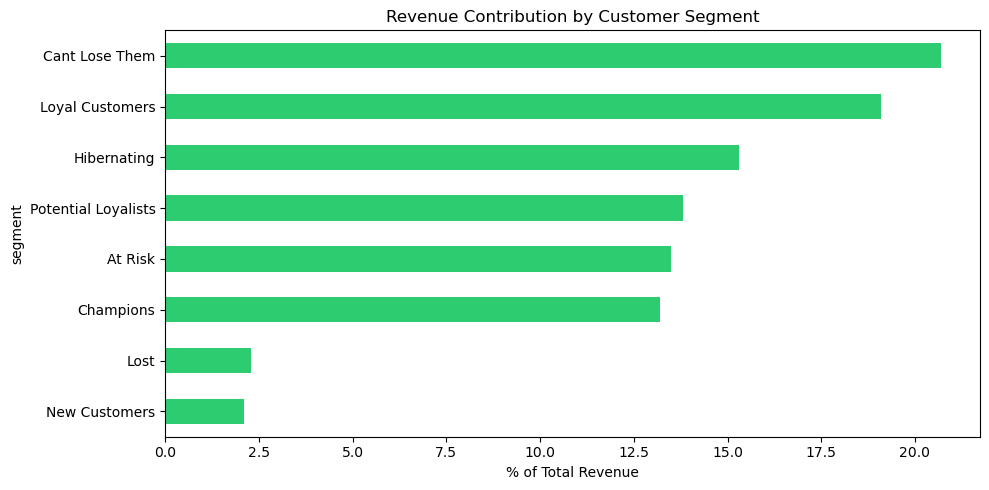

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
segment_revenue['revenue_pct'].plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_xlabel('% of Total Revenue')
ax.set_title('Revenue Contribution by Customer Segment')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

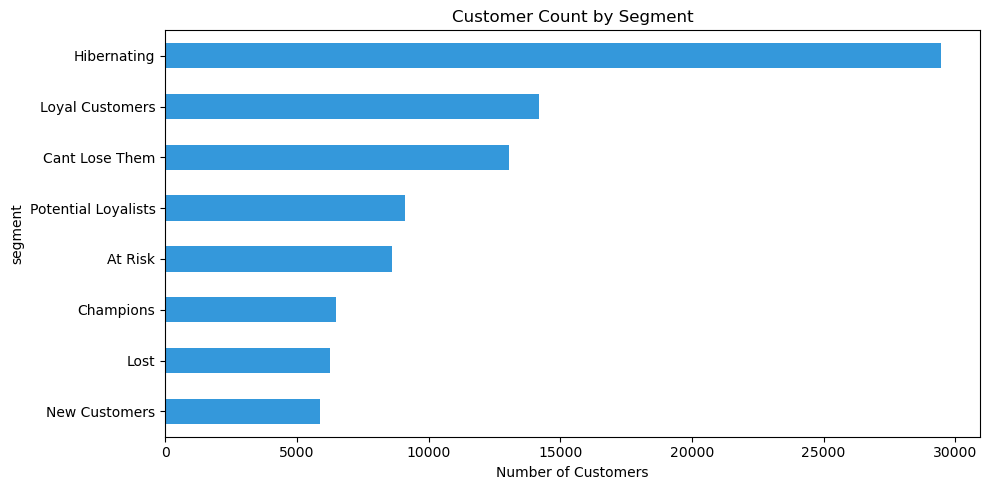

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
rfm['segment'].value_counts().plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Number of Customers')
ax.set_title('Customer Count by Segment')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
rfm.to_csv('rfm_segments.csv')
print('Saved!')

Saved!
